In [38]:
import pandas as pd
import io
import json
import numpy as np
import tensorflow as tf

I0000 00:00:1781214903.460512  243490 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [62]:
models = ["gruSimple" , "gru", "lstm", "convlstm", "transformer"]
files_and_names = [(f, f.replace("-data_result.json", "").replace("building", "Building ") ) for f in ["buildingA-data_result.json","buildingB-data_result.json","buildingC-data_result.json"]]

In [65]:
WEIGTH_DIRECTORY = "../../metrics/{}/HFL/weigths/results/"
global_model_key = "global_model"
weigths_by_type = {}
for model in models:
    weigths_by_type[model] = {}
    directory = WEIGTH_DIRECTORY.format(model)
    pesos = []
    for file, name in files_and_names:
        with open(directory+file) as f:
            pesos  = json.loads(f.read())["arrays"]
        weigths_by_type[model][name] = pesos

In [67]:
GLOBAL_MODEL = "../../metrics/{}/HFL/weigths/global_model.npz"
for model in models:
    loaded = np.load(GLOBAL_MODEL.format(model))
    arrays = [loaded[k].tolist() for k in loaded.files]
    weigths_by_type[model][global_model_key] = arrays

In [68]:
cosine_sim = tf.keras.metrics.CosineSimilarity()

In [ ]:
cosines_dfs = {}
for model in models :
    baseline = weigths_by_type[model][global_model_key]
    similarity_rows = []
    for _, name in files_and_names:
        layer_sims = []
        for base_layer, model_layer in zip(baseline, weigths_by_type[model][name]):
            base_vec = tf.constant(np.asarray(base_layer).ravel(), dtype=tf.float32)
            model_vec = tf.constant(np.asarray(model_layer).ravel(), dtype=tf.float32)
            cosine_sim.reset_state()
            layer_sim = float(cosine_sim(base_vec, model_vec).numpy())
            layer_sims.append(layer_sim)
        similarity_rows.append(layer_sims)

    layer_names = [f"L{i}" for i in range(len(baseline))]
    cosine_df = pd.DataFrame(similarity_rows, index=[name for file, name in files_and_names], columns=layer_names)
    cosines_dfs[model] = cosine_df

<Axes: >

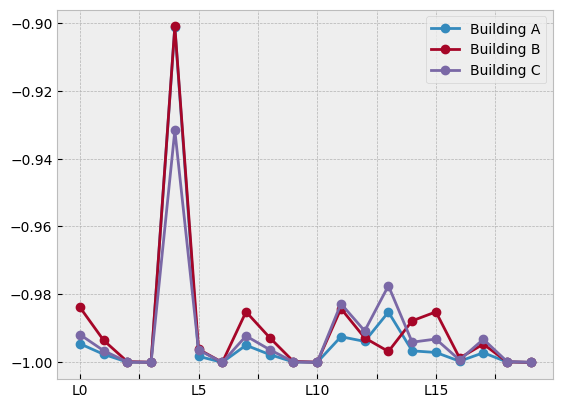

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('bmh')
cosines_dfs['convlstm'].T.plot(kind = 'line', marker = 'o')
#sns.lineplot(data=cosine_df, x=)